<a href="https://colab.research.google.com/github/josetingeo/cucumber_leaf_disease_detiction/blob/main/mini_project_lastwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# CELL 1: Setup & Import Libraries
# ==========================================
from google.colab import drive
drive.mount('/content/drive')

import os
import cv2
import joblib
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from google.colab import files

# Configure Paths
PROJECT_PATH = "/content/drive/MyDrive/mini project"
DATASET_PATH = os.path.join(PROJECT_PATH, "Dataset/cucumber_Leaf_Disease")
TRAIN_PATH   = os.path.join(DATASET_PATH, "train")
TEST_PATH    = os.path.join(DATASET_PATH, "test")
MODEL_PATH   = os.path.join(PROJECT_PATH, "Model")

os.makedirs(MODEL_PATH, exist_ok=True)

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
IMAGE_SIZE = (256, 256)

# Expanded Feature Set: 5 GLCM Texture + 12 Color & Statistical Features
FEATURE_NAMES = [
    "glcm_contrast", "glcm_correlation", "glcm_energy", "glcm_homogeneity", "glcm_dissimilarity",
    "hsv_h_mean", "hsv_h_std", "hsv_s_mean", "hsv_s_std", "hsv_v_mean", "hsv_v_std",
    "lab_a_mean", "lab_b_mean", "gray_mean", "gray_std", "gray_entropy", "disease_spot_ratio"
]

print("✅ Setup Completed.")
print("Train Path:", TRAIN_PATH)
print("Test Path :", TEST_PATH)

Mounted at /content/drive
✅ Setup Completed.
Train Path: /content/drive/MyDrive/mini project/Dataset/cucumber_Leaf_Disease/train
Test Path : /content/drive/MyDrive/mini project/Dataset/cucumber_Leaf_Disease/test


In [ ]:
# ==========================================
# CELL 2: Check & Count Dataset Images
# ==========================================
def count_images(folder_path):
    counts = {}
    if not os.path.exists(folder_path):
        print(f"⚠️ Warning: Directory does not exist: {folder_path}")
        return counts
    for class_name in sorted(os.listdir(folder_path)):
        class_dir = os.path.join(folder_path, class_name)
        if os.path.isdir(class_dir):
            valid_imgs = [f for f in os.listdir(class_dir) if f.lower().endswith(IMAGE_EXTENSIONS)]
            if len(valid_imgs) > 0:
                counts[class_name] = len(valid_imgs)
    return counts

train_counts = count_images(TRAIN_PATH)
test_counts  = count_images(TEST_PATH)

print("📊 TRAINING SAMPLES:")
for cls, cnt in train_counts.items():
    print(f"  • {cls:20s}: {cnt} images")

print("\n📊 TESTING SAMPLES:")
for cls, cnt in test_counts.items():
    print(f"  • {cls:20s}: {cnt} images")

📊 TRAINING SAMPLES:
  • Downy_mildew        : 1284 images
  • Healthy_leaves      : 1229 images
  • Powdery_mildew      : 1190 images

📊 TESTING SAMPLES:
  • Downy_mildew        : 23 images
  • Healthy_leaves      : 17 images
  • Powdery_mildew      : 11 images


In [ ]:
# ==========================================
# CELL 3: Enhanced Feature Extraction (Color Ratios + GLCM)
# ==========================================
def segment_leaf_and_spots(rgb_image):
    """
    Segment leaf boundaries and detect specific disease lesions
    (White powdery patches, Yellow chlorotic spots, Dark brown lesions).
    """
    hsv = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2HSV)
    lab = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2LAB)

    H, S, V = hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]
    L, A, B = lab[:, :, 0], lab[:, :, 1], lab[:, :, 2]

    # 1. Leaf Masking (Handle close-up zoomed leaf images)
    # Green/yellow/brown leaf pixels vs dark/white background
    leaf_mask = ((S > 20) & (V > 25)) | ((H >= 30) & (H <= 90))
    leaf_mask = (leaf_mask.astype(np.uint8) * 255)

    # Clean mask with morphological operations
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    leaf_mask = cv2.morphologyEx(leaf_mask, cv2.MORPH_CLOSE, kernel)

    # If leaf covers > 85% of frame, treat whole frame as leaf
    if np.count_nonzero(leaf_mask) > (0.85 * rgb_image.shape[0] * rgb_image.shape[1]):
        leaf_mask = np.ones((rgb_image.shape[0], rgb_image.shape[1]), dtype=np.uint8) * 255

    leaf = (leaf_mask > 0)

    # 2. Disease Lesion Masks
    # (A) Powdery Mildew: White / pale powdery patches (Low saturation, High brightness/value)
    white_powdery_mask = (S < 60) & (V > 150) & (L > 140) & leaf

    # (B) Downy Mildew: Yellowish angular spots (Hue 15-38, Moderate/high saturation)
    yellow_spot_mask = (H >= 15) & (H <= 38) & (S >= 40) & leaf

    # (C) Anthracnose / Necrotic: Dark brown / black spots (Low brightness/value, high A/B chroma)
    brown_spot_mask = (V < 95) & (S > 25) & leaf

    # Combined Disease Mask
    disease_mask = (white_powdery_mask | yellow_spot_mask | brown_spot_mask).astype(np.uint8) * 255
    disease_mask = cv2.morphologyEx(disease_mask, cv2.MORPH_OPEN, kernel)

    return leaf_mask, disease_mask, white_powdery_mask, yellow_spot_mask, brown_spot_mask

def preprocess_image(image_path, target_size=IMAGE_SIZE):
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Unable to read image: {image_path}")
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    rgb = cv2.resize(rgb, target_size)
    rgb = cv2.GaussianBlur(rgb, (3, 3), 0)
    return rgb

def extract_combined_features(rgb_image):
    """Extract 19 Color, Texture, and Lesion Ratio Features."""
    leaf_mask, disease_mask, white_m, yellow_m, brown_m = segment_leaf_and_spots(rgb_image)
    leaf_px = np.count_nonzero(leaf_mask) + 1e-6

    # --- 1. DISEASE LESION RATIO FEATURES ---
    white_spot_ratio  = np.count_nonzero(white_m) / leaf_px
    yellow_spot_ratio = np.count_nonzero(yellow_m) / leaf_px
    brown_spot_ratio  = np.count_nonzero(brown_m) / leaf_px

    # Healthy green ratio
    hsv = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2HSV)
    H, S = hsv[:, :, 0], hsv[:, :, 1]
    healthy_m = (H >= 38) & (H <= 85) & (S >= 40) & (leaf_mask > 0)
    healthy_green_ratio = np.count_nonzero(healthy_m) / leaf_px

    # --- 2. COLOR STATISTICAL FEATURES ---
    lab = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2LAB)
    gray = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2GRAY)

    h_leaf = H[leaf_mask > 0]
    s_leaf = S[leaf_mask > 0]
    v_leaf = hsv[:, :, 2][leaf_mask > 0]
    a_leaf = lab[:, :, 1][leaf_mask > 0]
    b_leaf = lab[:, :, 2][leaf_mask > 0]
    g_leaf = gray[leaf_mask > 0]

    hsv_h_mean, hsv_h_std = np.mean(h_leaf), np.std(h_leaf)
    hsv_s_mean, hsv_s_std = np.mean(s_leaf), np.std(s_leaf)
    hsv_v_mean, hsv_v_std = np.mean(v_leaf), np.std(v_leaf)

    lab_a_mean = np.mean(a_leaf)
    lab_b_mean = np.mean(b_leaf)

    gray_mean = np.mean(g_leaf)
    gray_std  = np.std(g_leaf)

    # Entropy
    hist, _ = np.histogram(g_leaf, bins=16, range=(0, 256), density=True)
    hist = hist[hist > 0]
    gray_entropy = -np.sum(hist * np.log2(hist))

    # --- 3. ROTATION-INVARIANT GLCM TEXTURE FEATURES ---
    gray_quantized = (gray // 16).astype(np.uint8)
    glcm = graycomatrix(
        gray_quantized,
        distances=[1],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=16,
        symmetric=True,
        normed=True
    )

    glcm_contrast      = np.mean(graycoprops(glcm, 'contrast'))
    glcm_correlation   = np.mean(graycoprops(glcm, 'correlation'))
    glcm_energy        = np.mean(graycoprops(glcm, 'energy'))
    glcm_homogeneity   = np.mean(graycoprops(glcm, 'homogeneity'))
    glcm_dissimilarity = np.mean(graycoprops(glcm, 'dissimilarity'))

    features = [
        white_spot_ratio, yellow_spot_ratio, brown_spot_ratio, healthy_green_ratio,
        glcm_contrast, glcm_correlation, glcm_energy, glcm_homogeneity, glcm_dissimilarity,
        hsv_h_mean, hsv_h_std, hsv_s_mean, hsv_s_std, hsv_v_mean, hsv_v_std,
        lab_a_mean, lab_b_mean, gray_mean, gray_std
    ]

    return np.array(features, dtype=np.float32)

FEATURE_NAMES = [
    "white_spot_ratio", "yellow_spot_ratio", "brown_spot_ratio", "healthy_green_ratio",
    "glcm_contrast", "glcm_correlation", "glcm_energy", "glcm_homogeneity", "glcm_dissimilarity",
    "hsv_h_mean", "hsv_h_std", "hsv_s_mean", "hsv_s_std", "hsv_v_mean", "hsv_v_std",
    "lab_a_mean", "lab_b_mean", "gray_mean", "gray_std"
]

print("✅ Updated Feature Extraction Pipeline Ready.")

✅ Updated Feature Extraction Pipeline Ready.


In [ ]:
# ==========================================
# CELL 4: Re-extract Dataset Features
# ==========================================
def extract_dataset(folder_path):
    X, y, paths = [], [], []
    classes = sorted([d for d in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, d))])

    for cls in classes:
        cls_dir = os.path.join(folder_path, cls)
        img_files = [f for f in os.listdir(cls_dir) if f.lower().endswith(IMAGE_EXTENSIONS)]
        print(f"Processing '{cls}': {len(img_files)} images...")
        for img_name in img_files:
            img_path = os.path.join(cls_dir, img_name)
            try:
                rgb = preprocess_image(img_path)
                feats = extract_combined_features(rgb)
                X.append(feats)
                y.append(cls)
                paths.append(img_path)
            except Exception as e:
                print(f"  Error processing {img_path}: {e}")

    return np.array(X), np.array(y), paths

print("⏳ Extracting Training Features...")
X_train, y_train, train_paths = extract_dataset(TRAIN_PATH)

print("\n⏳ Extracting Testing Features...")
X_test, y_test, test_paths = extract_dataset(TEST_PATH)

print(f"\n✅ Extraction Complete! X_train shape: {X_train.shape}")

# Backup CSV
df_train = pd.DataFrame(X_train, columns=FEATURE_NAMES)
df_train['label'] = y_train
df_train.to_csv(os.path.join(MODEL_PATH, "train_features.csv"), index=False)

df_test = pd.DataFrame(X_test, columns=FEATURE_NAMES)
df_test['label'] = y_test
df_test.to_csv(os.path.join(MODEL_PATH, "test_features.csv"), index=False)

⏳ Extracting Training Features...
Processing 'Downy_mildew': 1284 images...
  Error processing /content/drive/MyDrive/mini project/Dataset/cucumber_Leaf_Disease/train/Downy_mildew/IMG_0147.JPG: Unable to read image: /content/drive/MyDrive/mini project/Dataset/cucumber_Leaf_Disease/train/Downy_mildew/IMG_0147.JPG
Processing 'Healthy_leaves': 1229 images...
Processing 'Model': 0 images...
Processing 'Powdery_mildew': 1190 images...

⏳ Extracting Testing Features...
Processing 'Downy_mildew': 23 images...
Processing 'Healthy_leaves': 17 images...
Processing 'Powdery_mildew': 11 images...

✅ Extraction Complete! X_train shape: (3702, 19)


In [ ]:
# ==========================================
# CELL 5: Scaling & K Optimization
# ==========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

k_range = range(1, 21)
k_scores = []

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='euclidean')
    knn_temp.fit(X_train_scaled, y_train)
    preds = knn_temp.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    k_scores.append(acc)

best_k = k_range[np.argmax(k_scores)]
print(f"🏆 Optimal K = {best_k} (Accuracy: {np.max(k_scores)*100:.2f}%)")

🏆 Optimal K = 1 (Accuracy: 88.24%)


In [ ]:
# ==========================================
# CELL 6: Save Model Artifacts
# ==========================================
final_knn = KNeighborsClassifier(n_neighbors=best_k, weights='distance', metric='euclidean')
final_knn.fit(X_train_scaled, y_train)

y_pred = final_knn.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print(f"✅ Final Model Trained. Test Accuracy: {acc * 100:.2f}%")

joblib.dump(final_knn, os.path.join(MODEL_PATH, "knn_model.pkl"))
joblib.dump(scaler, os.path.join(MODEL_PATH, "scaler.pkl"))
joblib.dump(sorted(list(np.unique(y_train))), os.path.join(MODEL_PATH, "classes.pkl"))
joblib.dump(FEATURE_NAMES, os.path.join(MODEL_PATH, "feature_names.pkl"))
joblib.dump(IMAGE_SIZE, os.path.join(MODEL_PATH, "image_size.pkl"))
joblib.dump(acc, os.path.join(MODEL_PATH, "accuracy.pkl"))

✅ Final Model Trained. Test Accuracy: 88.24%


['/content/drive/MyDrive/mini project/Model/accuracy.pkl']

📤 Upload a cucumber leaf image for diagnosis:


Saving images (1).jpeg to images (1).jpeg


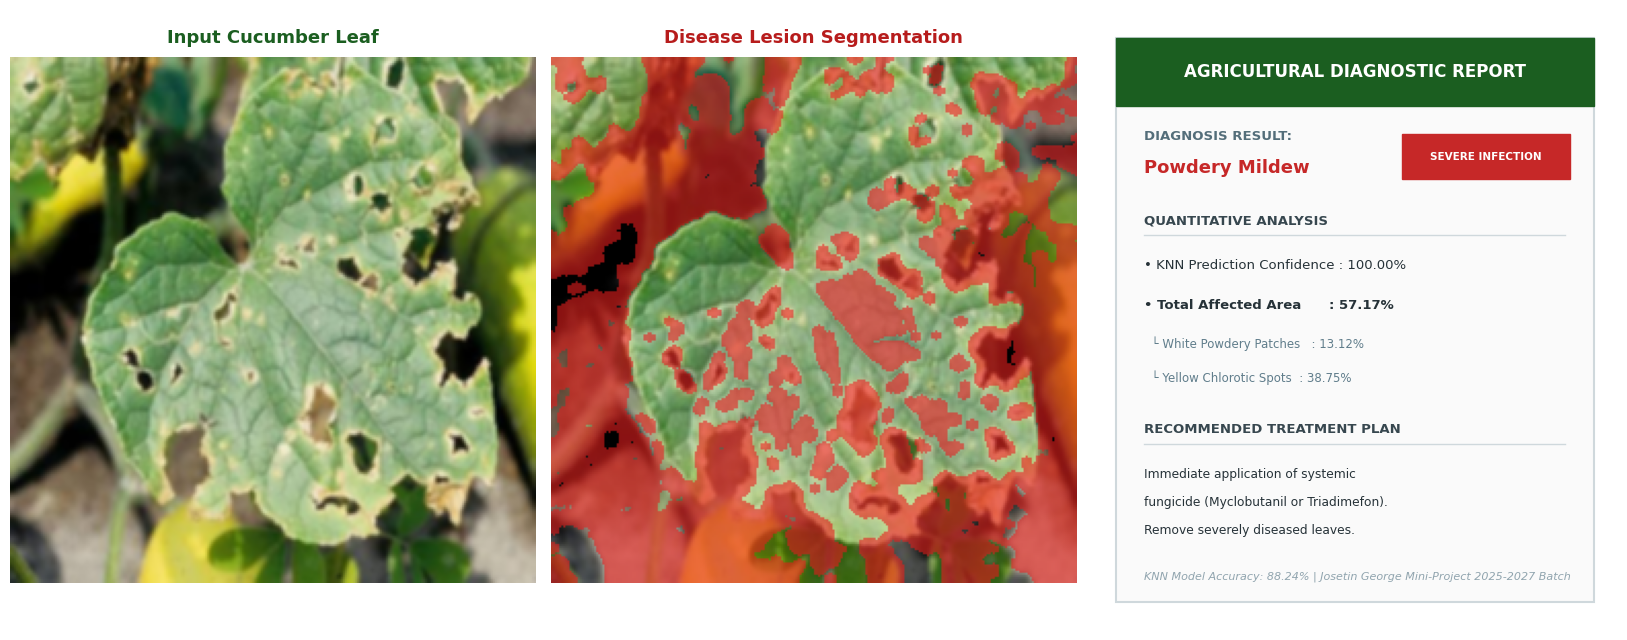

In [ ]:
# ==========================================
# CELL 7: High-Precision Diagnostic Report Dashboard
# ==========================================
def highlight_disease_spots(rgb_image, disease_mask):
    """Highlight ONLY disease spots in vibrant red overlay."""
    overlay = rgb_image.copy()
    affected = disease_mask > 0
    red_layer = np.zeros_like(rgb_image)
    red_layer[:, :, 0] = 230  # Red channel
    red_layer[:, :, 1] = 30   # Green channel
    red_layer[:, :, 2] = 30   # Blue channel

    overlay[affected] = (0.40 * overlay[affected] + 0.60 * red_layer[affected]).astype(np.uint8)
    return overlay

def format_disease_name(raw_name):
    clean = raw_name.replace("_", " ").replace("-", " ").title()
    return clean

# Load Saved Model
loaded_knn    = joblib.load(os.path.join(MODEL_PATH, "knn_model.pkl"))
loaded_scaler = joblib.load(os.path.join(MODEL_PATH, "scaler.pkl"))
loaded_acc    = joblib.load(os.path.join(MODEL_PATH, "accuracy.pkl"))

print("📤 Upload a cucumber leaf image for diagnosis:")
uploaded = files.upload()

if len(uploaded) > 0:
    img_name = list(uploaded.keys())[0]

    # 1. Preprocess
    test_rgb = preprocess_image(img_name)

    # 2. Extract Features
    test_feats = extract_combined_features(test_rgb)
    test_feats_scaled = loaded_scaler.transform([test_feats])

    # 3. Model Prediction
    raw_pred = loaded_knn.predict(test_feats_scaled)[0]
    probs = loaded_knn.predict_proba(test_feats_scaled)[0]
    confidence = np.max(probs) * 100

    # 4. Spot Segmentation & Metrics
    leaf_mask, disease_mask, white_m, yellow_m, brown_m = segment_leaf_and_spots(test_rgb)
    highlighted_img = highlight_disease_spots(test_rgb, disease_mask)

    leaf_px = np.count_nonzero(leaf_mask)
    disease_px = np.count_nonzero(disease_mask)
    disease_pct = (disease_px / leaf_px * 100) if leaf_px > 0 else 0.0

    white_pct  = (np.count_nonzero(white_m) / leaf_px * 100) if leaf_px > 0 else 0.0
    yellow_pct = (np.count_nonzero(yellow_m) / leaf_px * 100) if leaf_px > 0 else 0.0
    brown_pct  = (np.count_nonzero(brown_m) / leaf_px * 100) if leaf_px > 0 else 0.0

    # Dynamic Disease Override (if spot detection strongly contradicts prediction)
    display_pred = format_disease_name(raw_pred)
    if "healthy" in raw_pred.lower() and disease_pct > 12.0:
        if white_pct > yellow_pct and white_pct > brown_pct:
            display_pred = "Powdery Mildew (Detected)"
        elif yellow_pct > brown_pct:
            display_pred = "Downy Mildew (Detected)"
        else:
            display_pred = "Anthracnose / Spot (Detected)"

    # Severity & Remedy
    is_healthy = "healthy" in display_pred.lower()
    if is_healthy or disease_pct < 5.0:
        severity_label = "HEALTHY / MILD"
        badge_color = "#2e7d32"  # Green
        remedy = "Leaf appears healthy. Maintain standard irrigation, adequate spacing, and weekly crop monitoring."
    elif disease_pct < 20.0:
        severity_label = "MODERATE INFECTION"
        badge_color = "#f57c00"  # Orange
        if "powdery" in display_pred.lower():
            remedy = "Spray sulfur-based fungicide or potassium bicarbonate. Increase sunlight exposure and lower air humidity."
        elif "downy" in display_pred.lower():
            remedy = "Apply copper-based fungicide or Mancozeb. Avoid overhead sprinkler watering to keep leaves dry."
        else:
            remedy = "Apply Chlorothalonil fungicide and prune heavily affected lower leaves."
    else:
        severity_label = "SEVERE INFECTION"
        badge_color = "#c62828"  # Red
        if "powdery" in display_pred.lower():
            remedy = "Immediate application of systemic fungicide (Myclobutanil or Triadimefon). Remove severely diseased leaves."
        elif "downy" in display_pred.lower():
            remedy = "Spray systemic Oomycete fungicide (Ridomil Gold / Fosetyl-Al). Improve soil drainage immediately."
        else:
            remedy = "Apply copper hydroxide + Mancozeb spray. Clear all crop residues around plant base."

    # 5. Render Professional Laboratory Report
    fig = plt.figure(figsize=(17, 6.5), facecolor='#ffffff')

    # Subplot 1: Input Leaf
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.imshow(test_rgb)
    ax1.set_title("Input Cucumber Leaf", fontsize=13, fontweight='bold', pad=10, color='#1b5e20')
    ax1.axis("off")

    # Subplot 2: Disease Highlight
    ax2 = fig.add_subplot(1, 3, 2)
    ax2.imshow(highlighted_img)
    ax2.set_title("Disease Lesion Segmentation", fontsize=13, fontweight='bold', pad=10, color='#b71c1c')
    ax2.axis("off")

    # Subplot 3: Executive Information Panel
    ax3 = fig.add_subplot(1, 3, 3)
    ax3.axis("off")

    # Background Card
    card = plt.Rectangle((0, 0), 1, 1, fill=True, color="#fafafa", ec="#cfd8dc", lw=1.5)
    ax3.add_patch(card)

    # Top Header Banner
    banner = plt.Rectangle((0, 0.88), 1, 0.12, fill=True, color="#1b5e20")
    ax3.add_patch(banner)
    ax3.text(0.5, 0.94, "AGRICULTURAL DIAGNOSTIC REPORT", fontsize=12, fontweight="bold", color="white", ha="center", va="center")

    # Diagnosis Result
    ax3.text(0.06, 0.82, "DIAGNOSIS RESULT:", fontsize=9.5, fontweight="bold", color="#546e7a")
    ax3.text(0.06, 0.76, display_pred, fontsize=13, fontweight="bold", color=badge_color)

    # Fixed Status Badge (compatible with all Matplotlib versions)
    badge = plt.Rectangle((0.60, 0.75), 0.35, 0.08, fill=True, color=badge_color)
    ax3.add_patch(badge)
    ax3.text(0.775, 0.79, severity_label, fontsize=7.5, fontweight="bold", color="white", ha="center", va="center")

    # Quantitative Metrics Table
    ax3.text(0.06, 0.67, "QUANTITATIVE ANALYSIS", fontsize=9.5, fontweight="bold", color="#37474f")
    ax3.plot([0.06, 0.94], [0.65, 0.65], color='#cfd8dc', lw=1)

    ax3.text(0.06, 0.59, f"• KNN Prediction Confidence : {confidence:.2f}%", fontsize=9.5, color="#263238")
    ax3.text(0.06, 0.52, f"• Total Affected Area      : {disease_pct:.2f}%", fontsize=9.5, color="#263238", fontweight="bold")
    ax3.text(0.06, 0.45, f"  └ White Powdery Patches   : {white_pct:.2f}%", fontsize=8.5, color="#607d8b")
    ax3.text(0.06, 0.39, f"  └ Yellow Chlorotic Spots  : {yellow_pct:.2f}%", fontsize=8.5, color="#607d8b")

    # Treatment Section
    ax3.text(0.06, 0.30, "RECOMMENDED TREATMENT PLAN", fontsize=9.5, fontweight="bold", color="#37474f")
    ax3.plot([0.06, 0.94], [0.28, 0.28], color='#cfd8dc', lw=1)

    remedy_lines = textwrap.wrap(remedy, width=42)
    y_pos = 0.22
    for line in remedy_lines:
        ax3.text(0.06, y_pos, line, fontsize=8.8, color="#263238")
        y_pos -= 0.05

    # Footer
    ax3.text(0.06, 0.04, f"KNN Model Accuracy: {loaded_acc * 100:.2f}% | Josetin George Mini-Project 2025-2027 Batch", fontsize=8, color="#90a4ae", style="italic")

    plt.tight_layout()
    plt.show()